In [1]:
import torch
from torchrl.data import ReplayBuffer
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import stable_retro
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import os
from datetime import datetime

#### Mario Environment and Rewards

In [2]:
def compute_reward(prev_info, curr_info, done):
    reward = 0.0

    # --- Milestones ---
    if curr_info.get('midpoint_flag', 0) > prev_info.get('midpoint_flag', 0):
        reward += 5.0

    if curr_info.get('game_mode', 20) == 12 and prev_info.get('game_mode', 20) == 20:
        reward += 10.0

    # --- Powerups ---
    if curr_info.get('powerup_status', 0) > prev_info.get('powerup_status', 0):
        reward += 1.0

    # reward -= 0.001

    return reward


In [3]:
ACTIONS = [
    [0,0,0,0,0,0,0,0,0,0,0,0],  # nothing
    [0,0,0,0,0,0,0,1,0,0,0,0],  # right
    [1,0,0,0,0,0,0,1,0,0,0,0],  # right + B (jump)
    [0,1,0,0,0,0,0,1,0,0,0,0],  # right + Y (run)
    [1,1,0,0,0,0,0,1,0,0,0,0],  # right + B + Y (run jump)
    [1,0,0,0,0,0,0,0,0,0,0,0],  # B (jump in place)
    [0,0,0,0,0,0,1,0,0,0,0,0],  # left
    [1,0,0,0,0,0,1,0,0,0,0,0],  # left + B (jump left)
    [0,1,0,0,0,0,1,0,0,0,0,0],  # left + Y (run)
    [0,0,0,0,1,0,0,0,0,0,0,0],  # up
    [0,0,0,0,0,1,0,0,0,0,0,0],  # down
]

class SMWEnv(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Override the observation space to match your tuple state
        self.actions = ACTIONS
        self.observation_space = gym.spaces.Box(
            low=np.array([0, 0, 0, 0, -128, 0], dtype=np.float32),
            high=np.array([255, 9999, 255, 999, 128, 1], dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = gym.spaces.Discrete(len(ACTIONS))
        self.stuck_counter = 0
        self.last_x = 0
        self.max_x_reached = 0
        self.prev_info = {}

    def reset(self, **kwargs):
        _, info = self.env.reset(**kwargs)
        self.prev_info = {'x': 0, 'midpoint_flag': 0, 'lives': 4, 'game_mode': 20}
        self.max_x_reached = 0
        obs = self.get_obs(info)
        return obs, info

    def step(self, action):
        actual_action = self.actions[action]
        _, _, terminated, truncated, info = self.env.step(actual_action)
        obs = self.get_obs(info)
        reward = compute_reward(self.prev_info, info, terminated or truncated)
        curr_x = info.get('x', 0)
        curr_pos = info.get('screen', 0) * 256 + curr_x
        if curr_pos > self.max_x_reached:
            reward += (curr_pos - self.max_x_reached) * 0.02
            self.max_x_reached = curr_pos

        curr_time = info.get('timer_h', 0) * 100 + info.get('timer_t', 0) * 10 + info.get('timer_o', 0)
        if curr_time == 0:
            terminated = True
            reward -= 3.0
        if info.get('game_mode', 20) == 11 and self.prev_info.get('game_mode', 20) == 20:
            terminated = True
            reward -= 3.0
        if info.get('game_mode', 20) == 12 and self.prev_info.get('game_mode', 20) == 20:
            terminated = True


        if curr_x == self.last_x:
            self.stuck_counter += 1
        else:
            self.stuck_counter = 0
            self.last_x = curr_x

        if self.stuck_counter > 600:
            terminated = True
            reward -= 4.5
            self.stuck_counter = 0

        self.prev_info = info
        return obs, reward, terminated, truncated, info

    def get_obs(self, info):
        curr_time = info.get('timer_h', 0) * 100 + info.get('timer_t', 0) * 10 + info.get('timer_o', 0)
        mario_x = info.get('x', 0)
        mario_x_local = mario_x % 256
        if info.get('sprite1_x', 0) == 0:
            sprite1_dist = 0.0  # no sprite, neutral signal
        else:
            sprite1_dist = float(np.clip(info.get('sprite1_x', 0) - mario_x_local, -128, 128))
        return np.array([
            info.get('screen', 0),
            mario_x,
            info.get('y', 0),
            curr_time,
            sprite1_dist,
            info.get('midpoint_flag', 0),
        ], dtype=np.float32)

#### JERK Algorithm

In [4]:
try:
    base_env.close()
except:
    pass

In [5]:
base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode=None)
# base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode='human')
env = SMWEnv(base_env)

total_rewards = []
steps_per_ep  = []
max_x_per_ep  = []
actor_losses  = []
critic_losses = []

In [8]:
class JERK:
    def __init__(self, beta, jump_times, jump_presses, right_times, left_times, steps):
        self.beta = beta
        self.jump_times = jump_times
        self.jump_presses = jump_presses
        self.right_times = right_times
        self.left_times = left_times
        self.steps = steps

        self.S = []  # list of (trajectory, mean_reward) tuples
        self.T = 0
        self.best_x = 0
        self.log = []  # (T, num_trajectories, best_r, best_x)
        self.episode_log = []  # (episode, ep_reward, ep_max_x)
        self.episode_count = 0

    def _tick(self, env):
        self.best_x = max(self.best_x, env.max_x_reached)
        self.T += 1
        if self.T % 100 == 0:
            best_r = max(self.S, key=lambda x: x[1])[1] if self.S else 0.0
            print(f"T={self.T:>7} | trajectories={len(self.S)} | best_r={best_r:.2f} | best_x={self.best_x}")
            self.log.append((self.T, len(self.S), best_r, self.best_x))

    def plot(self):
        if not self.log:
            return
        ts, trajs, rewards, xs = zip(*self.log)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        ax1.plot(ts, rewards, color='tab:blue')
        ax1.set_ylabel('Best Reward')
        ax1.set_title('JERK - Super Mario World')

        ax2.plot(ts, xs, color='tab:green')
        ax2.set_ylabel('Best X Reached')

        ax3.plot(ts, trajs, color='tab:orange')
        ax3.set_ylabel('Trajectories in S')
        ax3.set_xlabel('Timestep')

        plt.tight_layout()
        plt.savefig('jerk_results.png', dpi=150)
        plt.show()

    def save(self, path='jerk_log.txt'):
        with open(path, 'w') as f:
            f.write('T,trajectories,best_r,best_x\n')
            for t, traj, r, x in self.log:
                f.write(f'{t},{traj},{r:.4f},{x}\n')
        print(f"Saved to {path}")
        with open(path.replace('.txt', '_episodes.txt'), 'w') as f:
            f.write('episode,reward,max_x\n')
            for ep, r, x in self.episode_log:
                f.write(f'{ep},{r:.4f},{x}\n')


    def rollout(self, env):
        RIGHT      = 1  # right
        RIGHT_JUMP = 2  # right + B
        LEFT       = 6  # left
        LEFT_JUMP  = 7  # left + B
        NO_OP      = 0  # nothing

        while self.T < self.steps:
            if len(self.S) > 0 and np.random.uniform(0, 1) < min(0.9, self.beta + self.T / self.steps):
                # --- Exploitation: replay best trajectory ---
                best_tau, best_r = max(self.S, key=lambda x: x[1])
                ep_reward = 0.0
                obs, _ = env.reset()
                done = False
                for i, action_idx in enumerate(best_tau):
                    obs, reward, terminated, truncated, info = env.step(action_idx)
                    ep_reward += reward
                    self._tick(env)
                    done = terminated or truncated
                    if done:
                        for _ in range(len(best_tau) - i - 1):
                            obs, reward, _, _, _ = env.step(NO_OP)
                            ep_reward += reward
                            self._tick(env)
                        break
                idx = self.S.index((best_tau, best_r))
                self.S[idx] = (best_tau, (best_r + ep_reward) / 2)
                self.episode_count += 1
                self.episode_log.append((self.episode_count, ep_reward, env.max_x_reached))

            else:
                # --- Exploration: go right with occasional jumps ---
                obs, _ = env.reset()
                done = False
                ep_trajectory = []
                ep_cumulative = []
                cumulative = 0.0
                prev_cumulative = 0.0
                jump_hold = 0

                while not done:
                    for _ in range(self.right_times):
                        if done:
                            break
                        if jump_hold > 0:
                            action_idx = RIGHT_JUMP
                            jump_hold -= 1
                        elif np.random.uniform(0, 1) < self.jump_presses:
                            action_idx = RIGHT_JUMP
                            jump_hold = self.jump_times - 1
                        else:
                            action_idx = RIGHT

                        obs, reward, terminated, truncated, info = env.step(action_idx)
                        ep_trajectory.append(action_idx)
                        cumulative += reward
                        ep_cumulative.append(cumulative)
                        self._tick(env)
                        done = terminated or truncated

                    if not done and cumulative <= prev_cumulative:
                        for step in range(self.left_times):
                            if done:
                                break
                            action_idx = LEFT_JUMP if step % self.jump_times == 0 else LEFT
                            obs, reward, terminated, truncated, info = env.step(action_idx)
                            ep_trajectory.append(action_idx)
                            cumulative += reward
                            ep_cumulative.append(cumulative)
                            self._tick(env)
                            done = terminated or truncated

                    prev_cumulative = cumulative

                if ep_cumulative:
                    best_t = int(np.argmax(ep_cumulative))
                    best_r = ep_cumulative[best_t]
                    best_tau = tuple(ep_trajectory[:best_t + 1])
                    self.S.append((best_tau, best_r))
                    self.episode_count += 1
                    ep_max_x = env.max_x_reached
                    self.episode_log.append((self.episode_count, cumulative, ep_max_x))


T=    100 | trajectories=0 | best_r=0.00 | best_x=386
T=    200 | trajectories=0 | best_r=0.00 | best_x=510
T=    300 | trajectories=0 | best_r=0.00 | best_x=634
T=    400 | trajectories=0 | best_r=0.00 | best_x=754
T=    500 | trajectories=0 | best_r=0.00 | best_x=796
T=    600 | trajectories=0 | best_r=0.00 | best_x=1052
T=    700 | trajectories=1 | best_r=26.16 | best_x=1308
T=    800 | trajectories=1 | best_r=26.16 | best_x=1308
T=    900 | trajectories=1 | best_r=26.16 | best_x=1308
T=   1000 | trajectories=1 | best_r=26.16 | best_x=1308
T=   1100 | trajectories=1 | best_r=26.16 | best_x=1308
T=   1200 | trajectories=1 | best_r=26.16 | best_x=1308
T=   1300 | trajectories=2 | best_r=26.16 | best_x=1308
T=   1400 | trajectories=2 | best_r=26.16 | best_x=1308
T=   1500 | trajectories=2 | best_r=26.16 | best_x=1308
T=   1600 | trajectories=2 | best_r=26.16 | best_x=1308
T=   1700 | trajectories=2 | best_r=26.16 | best_x=1308
T=   1800 | trajectories=2 | best_r=26.16 | best_x=1308
T= 

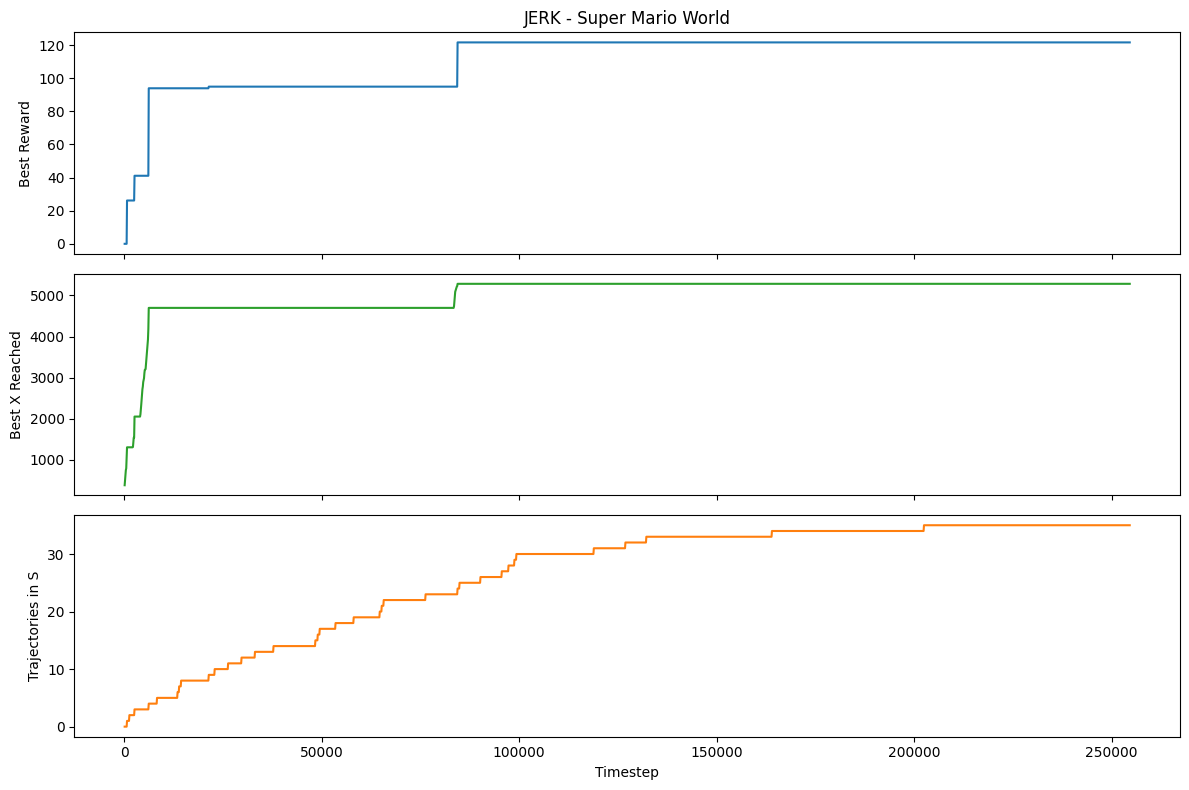

Saved to jerk_log.txt


In [9]:
agent = JERK(beta=0.25, jump_times=4, jump_presses=0.1, right_times=100, left_times=70, steps=250_000)
agent.rollout(env)
agent.plot()
agent.save('jerk_log.txt')